In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Running this notebook on: ", device)

import spateo as st
print("Last run with spateo version:", st.__version__)

# Other imports
import warnings, string
import anndata as ad
import dynamo as dyn
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Uncomment the following if running on the server
import pyvista as pv
pv.start_xvfb()
from matplotlib.colors import ListedColormap, rgb2hex
sns.set_theme(context="paper", style="ticks", font_scale=1)
warnings.filterwarnings('ignore')
# %load_ext autoreload
# %autoreload 2

Running this notebook on:  cpu


2025-03-01 01:30:21.689587: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/root/miniforge3/envs/spateo/lib/python3.8/site-packages/geopandas/_compat.py:124: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


fastpd is not installed. If you need mesh correction, please compile the fastpd library.
Last run with spateo version: 0.0.0


In [2]:
adata = st.read_h5ad('/data/work/tha_0116.h5ad')
adata

AnnData object with n_obs × n_vars = 3279854 × 33347
    obs: 'dnbCount', 'area', 'orig.ident', 'x', 'y', 'region', 'n_counts', 'region_h2', 'slice_code', 'sub_region', 'dmt_leiden', 'ADHD_2022_NatGenet', 'ADHD_adulthood_2022_NatGenet', 'ADHD_childhood_2022_NatGenet', 'PGC_ASD_2019_NatGenet', 'ILAE3_Caucasian_GGE_final', 'ILAE3_Caucasian_all_epilepsy_final', 'ILAE3_Caucasian_focal_epilepsy_final', 'Cognitive_Performance_2018_NatGenet', 'IQ_NG_2018', 'PGC3_SCZ_wave3_public_INFO80', 'PGC_Bipolar_INFO80_2021_NatGenet', 'MDD_Howard_2019_NN', 'Depression_2023_NatureMed', 'AD_2022_NatGenet', 'PD_Nalls_2019_Lancent_Neurology', 'sumstats_neuroticism_ctg_format', 'SESA_neuro_clus_sumstats', 'TS_Oct2018', 'PGC_ptsd_2019_NatComm', 'ALS2021', 'Insomnia_sumstats_Jansenetal', 'GIANT_EUR_Height_2022_Nature', 'Stroke_2022_Nature'
    uns: 'dmt_leiden_colors', 'dmt_nn', 'leiden', 'slice_code_colors'
    obsm: 'X_dmt', 'X_dmt_highdim', 'align_spatial_2d', 'align_spatial_3d', 'cell_border', 'latent_embed

In [3]:
adata.obs_names_make_unique()
slice_code = ['104_B03615F3G5_WT202405020035.h5ad',
 '105_D03468A4C6_WT202403310067.h5ad',
 '14_A03591A1C3_WT202403310045.h5ad',
 '16_A03592A4C6_WT202403310044.h5ad',
 '18_B03602C4D6_WT202405020031.h5ad',
 '20_B03606F3G5_WT202405020032.h5ad',
 '22_B03606C4E6_WT202403310050.h5ad',
 '23_B03609A4D6_WT202404150263.h5ad',
 '27_B03610C1E3_WT202403310051.h5ad',
 '31_B03619A1D3_WT202403310052.h5ad',
 '35_B03619E4G6_WT202403310053.h5ad',
 '39_A03589A1D4_WT202403310046.h5ad',
 '43_A03590E1G4_WT202403310064.h5ad',
 '47_A03593C1F3_WT202403310068.h5ad',
 '51_B03605C2E5_WT202406020126.h5ad',
 '55_B03613E3G6_WT202403310069.h5ad',
 '59_B03612E4G6_WT202403310059.h5ad',
 '63_B03606C1E3_WT202403310061.h5ad',
 '67_A03595A1D3_WT202403310062.h5ad',
 '71_A03595A4D6_WT202403310063.h5ad',
 '75_D03468D1E3_WT202403310066.h5ad',
 '80_D03473D4E6_WT202403310070.h5ad',
 '84_B03423D1E3_WT202403310065.h5ad',
 '89_D03466A1C3_WT202403310058.h5ad',
 '99_D03470D1E3_WT202404290071.h5ad',]

dic = {'0': 'T7_SST_LHX_SIX3',
 '1': 'T9_CRH',
 '10': 'T6_CLSTN2',
 '11': 'T4_COL4A1_vessel',
 '12': 'T3_BMP4_IGFBP5',
 '13': 'T7_SST_LHX_SIX3',
 '14': 'T0_PCP4_VGF',
 '15': 'T9_CRH',
 '16': 'T3_BMP4_IGFBP5',
 '17': 'T3_BMP4_IGFBP5',
 '18': 'T2_PRSS12',
 '19': 'T9_CRH',
 '2': 'T9_CRH',
 '20': 'T1_NTS_CALB1',
 '21': 'T1_NTS_CALB1',
 '22': 'T1_NTS_CALB1',
 '23': 'T10_HBZ',
 '24': 'T1_NTS_CALB1',
 '25': 'T1_NTS_CALB1',
 '26': 'T2_PRSS12',
 '27': 'T9_CRH',
 '28': 'T2_PRSS12',
 '29': 'T5_AQP4_gial_region',
 '3': 'T10_HBZ',
 '30': 'T8_CBLN4_CBLN1',
 '31': 'T7_SST_LHX_SIX3',
 '32': 'T9_CRH',
 '33': 'T1_NTS_CALB1',
 '34': 'T7_SST_LHX_SIX3',
 '35': 'T10_HBZ',
 '36': 'T8_CBLN4_CBLN1',
 '37': 'T9_CRH',
 '38': 'T3_BMP4_IGFBP5',
 '39': 'T1_NTS_CALB1',
 '4': 'T2_PRSS12',
 '40': 'T9_CRH',
 '41': 'T6_CLSTN2',
 '42': 'T10_HBZ',
 '5': 'T7_SST_LHX_SIX3',
 '6': 'T7_SST_LHX_SIX3',
 '7': 'T9_CRH',
 '8': 'T2_PRSS12',
 '9': 'T1_NTS_CALB1'}

adata.obs['dmt_leiden_annotation_0115'] = [dic[i] for i in adata.obs['dmt_leiden']]
colormap = {'T2_PRSS12': '#31d6d3',
 'T6_CLSTN2': '#6b0c4d',
 'T3_BMP4_IGFBP5': '#e94a1d',
 'T4_COL4A1_vessel': '#cf58e5',
 'T10_HBZ': '#39d789',
 'T7_SST_LHX_SIX3': '#4e7c26',
 'T8_CBLN4_CBLN1': '#eaccd8',
 'T1_NTS_CALB1': '#9114fb',
 'T9_CRH': '#79f4ec',
 'T0_PCP4_VGF': '#b3fcdd',
 'T5_AQP4_gial_region': '#455edf'}
adata = adata[adata.obs['slice_code'].isin(slice_code)].copy()

adata0 = adata[adata.obs['slice_code'] == '47_A03593C1F3_WT202403310068.h5ad']
adata1 = adata[adata.obs['slice_code'] != '47_A03593C1F3_WT202403310068.h5ad']

adata0.obsm['align_spatial_3d'] = np.array([adata0.obsm['align_spatial_2d'][:,0], 
                                            adata0.obsm['align_spatial_2d'][:,1],
                                            [1187.5 for _ in range(len(adata0))]]).T.copy()
adata = ad.concat([adata0, adata1])

In [4]:
thalamus = adata[adata.obs.sample(frac = 0.01).index].copy()
thalamus_pc_for_mesh, plot_cmap = st.tdr.construct_pc(adata=thalamus.copy(), 
                                                      spatial_key="align_spatial_3d", 
                                                      groupby="region_h2", key_added="tissue", colormap="rainbow")
thalamus_mesh, _, _ = st.tdr.construct_surface(pc=thalamus_pc_for_mesh, key_added="tissue",  color="#9EDAE5",
                                      alpha=1, cs_method="marching_cube", cs_args={"mc_scale_factor": 1.02}, 
                                      smooth=5000, scale_factor=1.08)

In [5]:
adata_p10 = adata[adata.obs.sample(frac = 0.1).index].copy()

In [29]:
thalamus_pc, plot_cmap = st.tdr.construct_pc(adata=adata_p10.copy(), 
                                             spatial_key="align_spatial_3d", 
                                             groupby="ALS2021",
                                             key_added="ALS2021",)

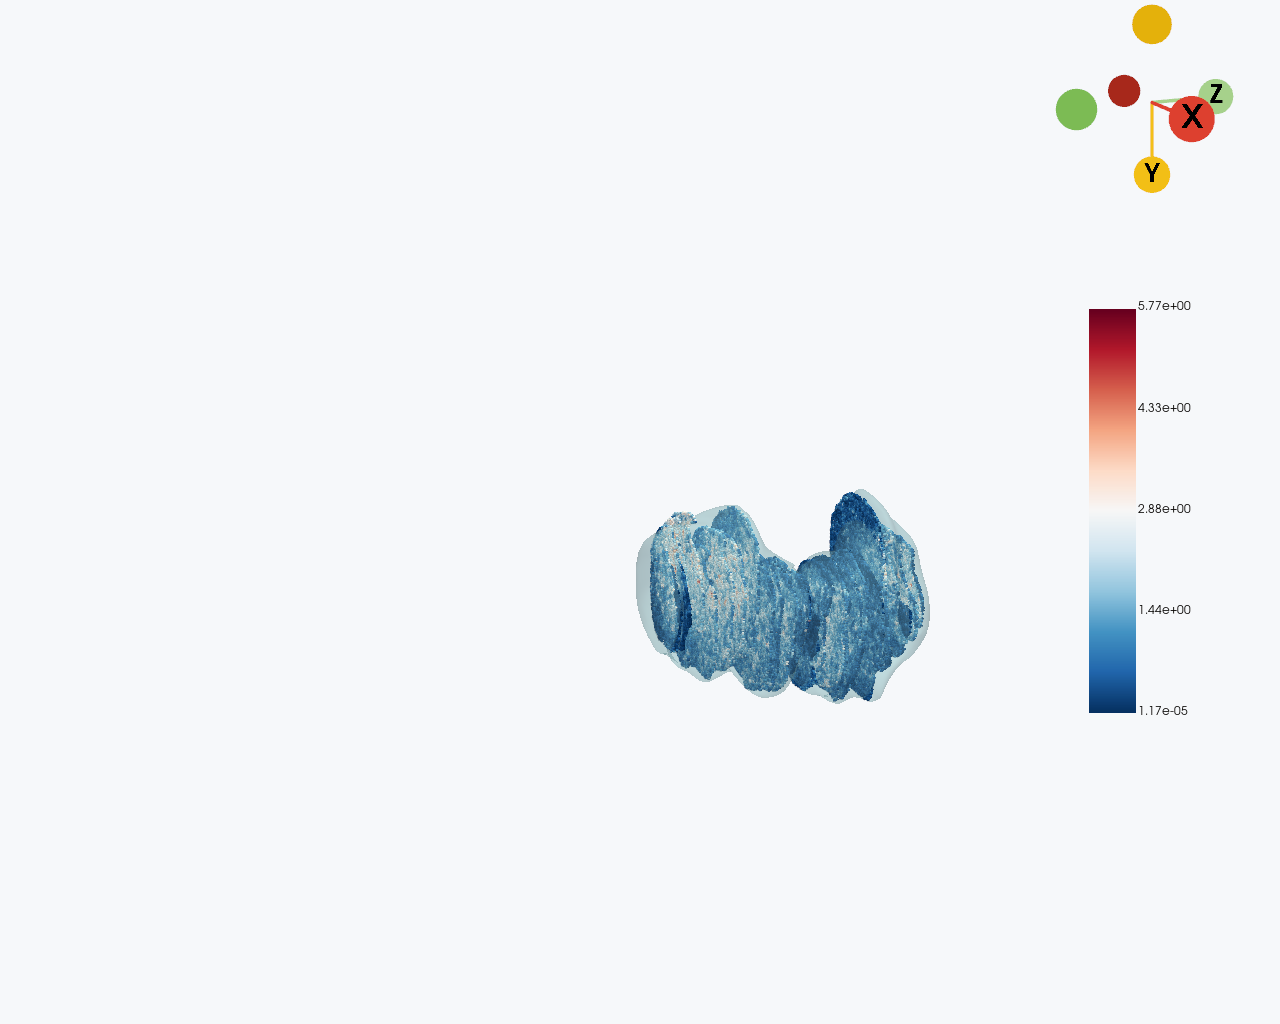

In [30]:
cpo =  [(10000, 0, -3000),  
        (1000, 2000, 1261.62304681),  
        (0, -1, 0)] 
st.pl.three_d_plot(model=st.tdr.collect_models([ thalamus_mesh, thalamus_pc]), 
                   key="tissue", model_style=['surface',"points"], jupyter=True,
                   opacity = [0.3, 1],
                   background = '#F6F8FA',
                   colormap = ['#9EDAE5', 'RdBu_r'],
                   cpo =  cpo, 
                   show_axes = True,
                  window_size = (1280, 1024),)